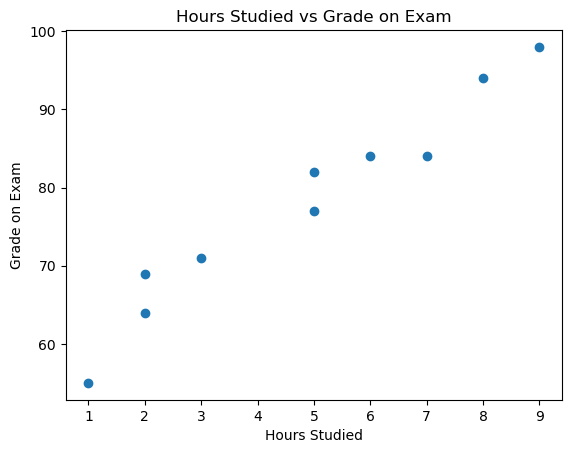

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [4]:
x = hours
y = grades

x_mean = x.mean()
y_mean = y.mean()

In [5]:
x_mean

np.float64(4.8)

In [6]:
y_mean

np.float64(77.8)

In [7]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


$$Y^h = \beta_0 + \beta_1 X$$

In [8]:
X = 10

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')

10 hours of work results 102.46153846153845


In [9]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
3,5,77
2,5,82
8,6,84
5,7,84
7,8,94
1,9,98


In [10]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours

print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


In [11]:
#pip install -U scikit-learn

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
X = hours.reshape(-1, 1)
y = grades

hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


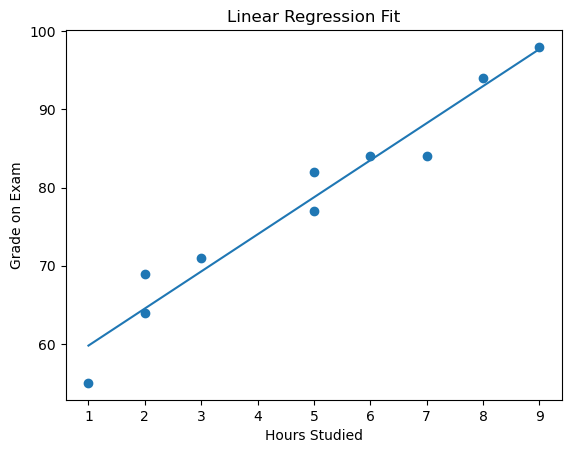

In [14]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

In [15]:
y_pred = hours_model.predict(X)
residuals = y - y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


In [16]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

In [17]:
print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")

R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


In [18]:
import pandas as pd

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [19]:
ads.shape

(4546, 5)

In [20]:
ads.describe()

,tv,radio,social_media,sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54062.912451,18157.533110,3323.472829,192413.332112
std,26104.941838,9663.259642,2211.253915,93019.873216
min,10000.000000,0.680000,0.030000,31199.410000
25%,32000.000000,10555.355000,1530.822500,112434.610000
50%,53000.000000,17859.515000,3055.565000,188963.680000
75%,77000.000000,25640.605000,4804.922500,272324.240000
max,100000.000000,48871.160000,13981.660000,364079.750000


In [36]:
from sklearn.linear_model import LinearRegression

channels = ['tv', 'radio', 'social_media']

from utils import rsquared

for channel in channels:

    X = ads[[channel]]
    y = ads['sales']

    model = LinearRegression()
    model.fit(X,y)

    y_hat = model.predict(X)
    r2 = rsquared(y,y_hat)
    rmse = np.sqrt(np.mean((y-y_hat)**2))

    print(f'Intercept {channel}: {model.intercept_:2f}')
    print(f'Coef {channel}: {model.coef_[0]:f}')
    print(f'R_Squared {channel}: {r2}')
    print(f'RMSE {channel}: {rmse}')
    print(100*'-')


Intercept tv: -132.492506
Coef tv: 3.561514
R_Squared tv: 0.9989949845239908
RMSE tv: 2948.589712935139
----------------------------------------------------------------------------------------------------
Intercept radio: 40586.800679
Coef radio: 8.361628
R_Squared radio: 0.7545316512195284
RMSE radio: 46081.40604818036
----------------------------------------------------------------------------------------------------
Intercept social_media: 118672.571739
Coef social_media: 22.187863
R_Squared social_media: 0.2781997280979549
RMSE social_media: 79019.9029555142
----------------------------------------------------------------------------------------------------


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

In [37]:
X.iloc[0]

social_media    2907.98
Name: 0, dtype: float64

In [38]:
def predict(n):
    y_hat = model.intercept_ + model.coef_*X.iloc[n]
    return y_hat

In [39]:
predict(2)

social_media    183314.914174
Name: 2, dtype: float64

In [40]:
model.predict(X)

array([183194.43407729, 172135.78119524, 183314.9141743 , ...,
       231746.13814231, 161736.32972793, 230644.7326146 ], shape=(4546,))

In [41]:
x_line

array([[3.00000000e-02],
       [7.02431216e+00],
       [1.40186243e+01],
       ...,
       [1.39676714e+04],
       [1.39746657e+04],
       [1.39816600e+04]], shape=(2000, 1))

In [42]:
corr = ads[['tv', 'radio', 'social_media', 'sales']].corr()
corr

,tv,radio,social_media,sales
tv,1.000000,0.869158,0.527687,0.999497
radio,0.869158,1.000000,0.606338,0.868638
social_media,0.527687,0.606338,1.000000,0.527446
sales,0.999497,0.868638,0.527446,1.000000


In [43]:
import plotly.express as px

fig = px.imshow(corr)
fig.show()

c:\Users\Ani\miniconda3\envs\aca\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


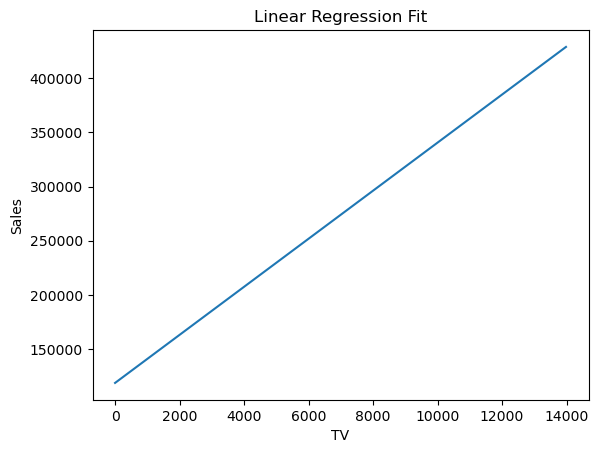

In [44]:
x_line = np.linspace(X.min(), X.max(), 2000).reshape(-1, 1)
y_line = model.predict(x_line)

import matplotlib.pyplot as plt

#plt.scatter(X, y)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

In [45]:
tv_new_budget = [[120000]]
tv_new_budget

[[120000]]

In [46]:
model.predict(tv_new_budget)

c:\Users\Ani\miniconda3\envs\aca\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2781216.15201795])

Multiple Linear Regression

In [47]:
X = ads[['tv', 'radio', 'social_media']]
y = ads['sales']

In [48]:
model = LinearRegression()
model.fit(X,y)
y_hat = model.predict(X)

In [49]:
rsquared(y, y_hat)

np.float64(0.9989950218000194)

In [54]:
from utils import rmse
rmse(y, y_hat)

np.float64(2948.5350308251286)

In [50]:
model.coef_

array([ 3.56256963, -0.00397038,  0.00496396])